# **03 Shap Analysis**

* This notebook applies SHAP to interpret the predictions of the trained XGBoost model.

* The analysis examines global feature importance, compares feature contributions across demographic groups, and provides local explanations for individual predictions.

* These analyses help identify how demographic and clinical features influence model behaviour and support the interpretation of the fairness audit results.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import pickle
import json
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
!pip install shap --quiet
import shap
print(f'SHAP version: {shap.__version__}')

PROCESSED_PATH = '/content/drive/MyDrive/Ethics project/processed/'
PLOTS_PATH     = '/content/drive/MyDrive/Ethics project/plots/'
os.makedirs(PLOTS_PATH, exist_ok=True)

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.dpi'       : 150,
})

# Load model and data
with open(PROCESSED_PATH + 'model_xgb_tuned.pkl', 'rb') as f:
    xgb_tuned = pickle.load(f)

with open(PROCESSED_PATH + 'config.json', 'r') as f:
    config = json.load(f)

test_df  = pd.read_csv(PROCESSED_PATH + 'test_df_with_preds.csv')
X_test_B = np.load(PROCESSED_PATH + 'X_test_B.npy')
y_test   = np.load(PROCESSED_PATH + 'y_test.npy')

FEATURES_B = config['features_B']
# ['age_years', 'sex_binary', 'age_group_enc', 'drug_enc']

# Clean feature names for plots
FEATURE_NAMES = {
    'age_years'    : 'Age (years)',
    'sex_binary'   : 'Sex (0=F, 1=M)',
    'age_group_enc': 'Age Group',
    'drug_enc'     : 'Drug Name'
}
DISPLAY_NAMES = [FEATURE_NAMES[f] for f in FEATURES_B]

print('=' * 55)
print('DATA LOADED')
print('=' * 55)
print(f'Test rows      : {len(test_df):,}')
print(f'Features (B)   : {FEATURES_B}')
print(f'Model          : XGBoost tuned without reaction')


Mounted at /content/drive
SHAP version: 0.52.0
DATA LOADED
Test rows      : 28,295
Features (B)   : ['age_years', 'sex_binary', 'age_group_enc', 'drug_enc']
Model          : XGBoost tuned without reaction


## Computing SHAP Values

* This computes SHAP values for the trained XGBoost model to explain its predictions.

* Mean absolute SHAP values are used to measure global feature importance, while the contributions of age and sex are examined to understand how demographic features influence model behaviour and support the fairness analysis.

In [ ]:
# ============================================================
# Computing SHAP Values
# ============================================================

print('Computing SHAP values...')

explainer   = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test_B)

print(f'SHAP values shape : {shap_values.shape}')
print(f'Features          : {FEATURES_B}')
print()

# Mean absolute SHAP per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Feature indices
sex_idx   = FEATURES_B.index('sex_binary')
age_idx   = FEATURES_B.index('age_years')
drg_idx   = FEATURES_B.index('drug_enc')
aggrp_idx = FEATURES_B.index('age_group_enc')

print('Mean |SHAP| per feature (global importance):')
print('-' * 45)
for feat, shap_val in sorted(
        zip(DISPLAY_NAMES, mean_abs_shap),
        key=lambda x: x[1], reverse=True):
    bar = '█' * int(shap_val * 500)
    print(f'  {feat:<20}: {shap_val:.5f}  {bar}')

print()

# SHAP splits the age signal between both features
# Combined age signal = sum of both
combined_age = mean_abs_shap[age_idx] + mean_abs_shap[aggrp_idx]
print('NOTE: age_years and age_group_enc are correlated features.')
print('SHAP splits the age signal between them.')
print(f'  age_years    SHAP : {mean_abs_shap[age_idx]:.5f}')
print(f'  age_group_enc SHAP: {mean_abs_shap[aggrp_idx]:.5f}')
print(f'  Combined age SHAP : {combined_age:.5f}  (true age influence)')

print()
sex_shap = mean_abs_shap[sex_idx]
drg_shap = mean_abs_shap[drg_idx]

print('KEY FINDING:')
print(f'  Drug importance      : {drg_shap:.5f}  (should be highest)')
print(f'  Combined age signal  : {combined_age:.5f}')
print(f'  Sex importance       : {sex_shap:.5f}')
print()
if sex_shap > 0.001:
    print('  Sex has non-negligible SHAP value')
    print('  Model IS using sex as a predictive signal')
    print('  This confirms demographic bias in predictions')
else:
    print('  Sex SHAP value near zero')
    print('  Bias may come through proxy features (drug, age)')


Computing SHAP values...
SHAP values shape : (28295, 4)
Features          : ['age_years', 'sex_binary', 'age_group_enc', 'drug_enc']

Mean |SHAP| per feature (global importance):
---------------------------------------------
  Drug Name           : 0.34839  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Age (years)         : 0.15754  ██████████████████████████████████████████████████████████████████████████████
  Sex (0=F, 1=M)      : 0.11272  ████████████████████████████████████████████████████████
  Age Group           : 0.04868  ████████████████████████

NOTE: age_years and age_group_enc are correlated features.
SHAP splits the age signal between them.
  age_years    SHAP : 0.15754
  age_group_enc SHAP: 0.04868
  Combined age SHAP : 0.20621  (true age influence)

KEY FINDING:
  Drug importance      : 0.34839  (should be highest)
  Combined age signal  : 0

Global SHAP Summary Plot
Each dot = one patient
Red = high feature value, Blue = low feature value
X axis = SHAP value (impact on prediction)



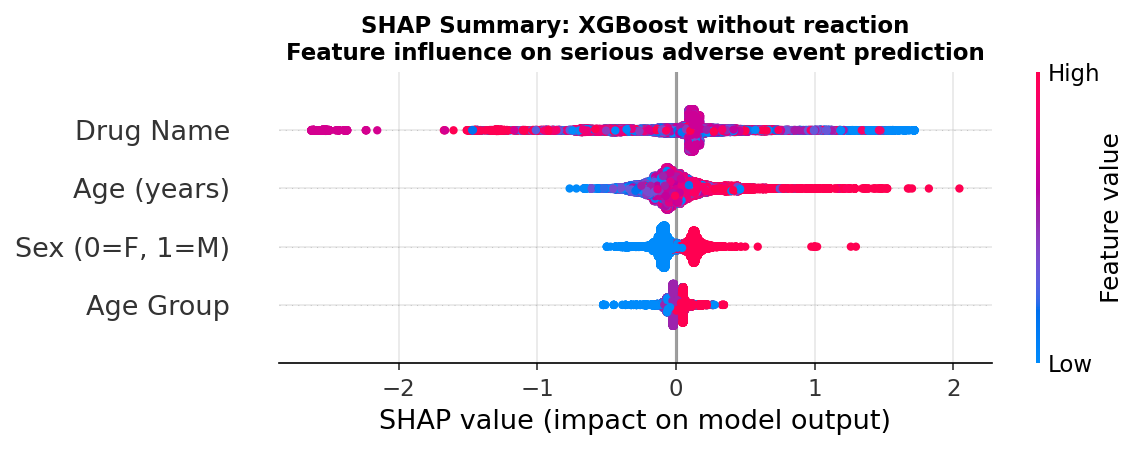

Saved: plots/12_shap_summary.png


In [ ]:
# ============================================================
# SHAP Summary Plot
# ============================================================

print('Global SHAP Summary Plot')
print('Each dot = one patient')
print('Red = high feature value, Blue = low feature value')
print('X axis = SHAP value (impact on prediction)')
print()

plt.figure(figsize=(10, 5))
shap.summary_plot(
    shap_values,
    X_test_B,
    feature_names = DISPLAY_NAMES,
    max_display   = len(FEATURES_B),
    show          = False
)
plt.title('SHAP Summary: XGBoost without reaction\n'
          'Feature influence on serious adverse event prediction',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_PATH + '12_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/12_shap_summary.png')


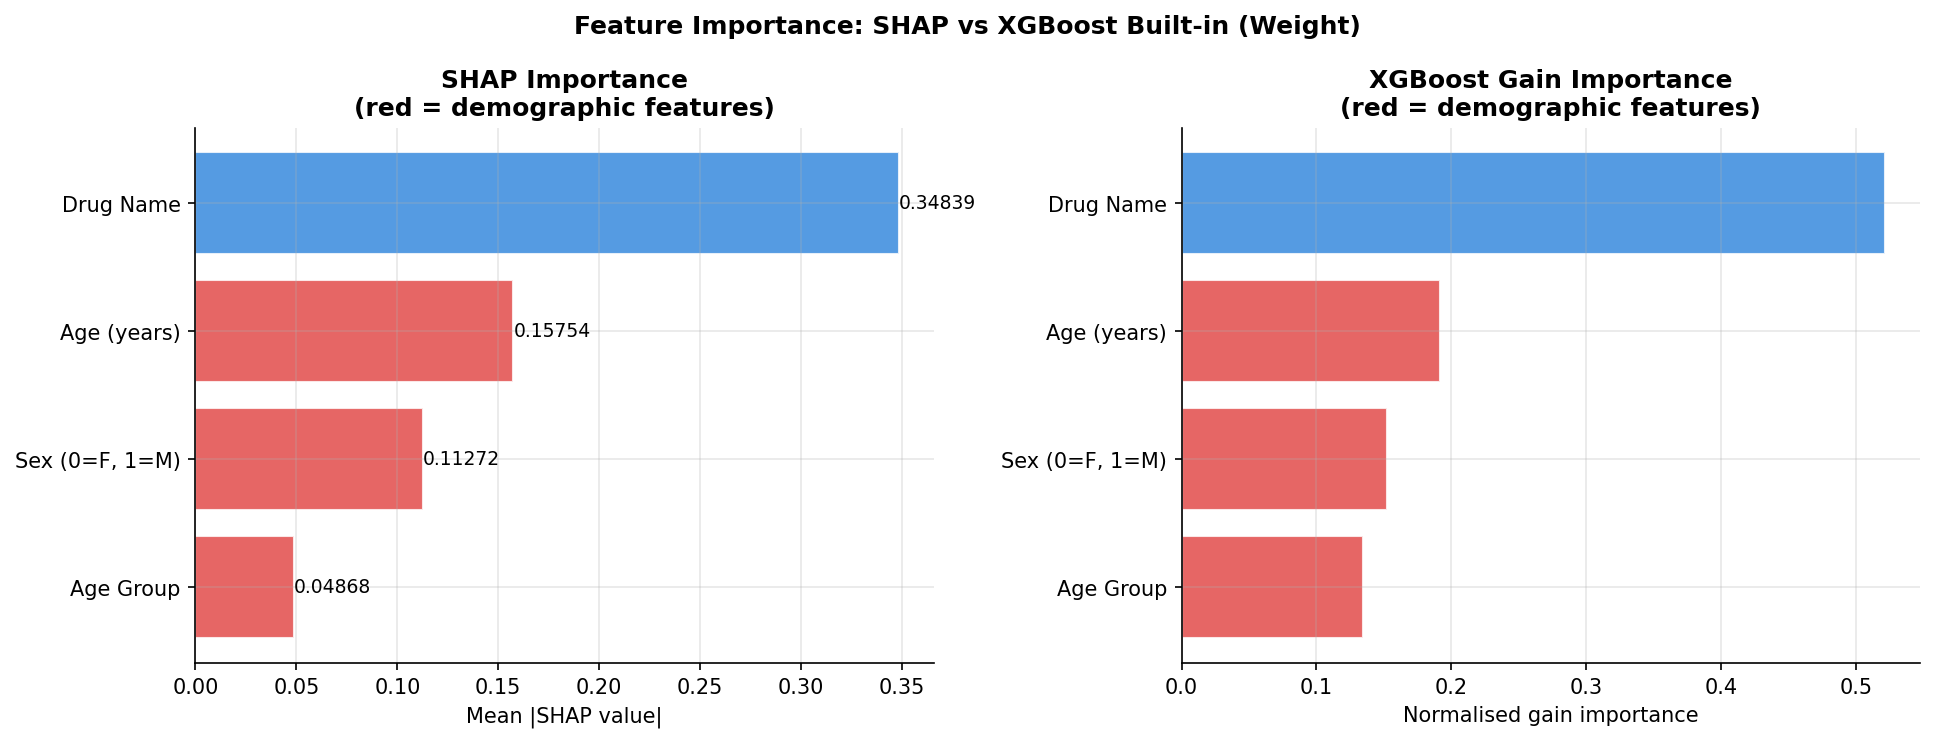

Saved: plots/13_feature_importance.png


In [ ]:
# ============================================================
# Feature Importance Bar Chart
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Feature Importance: SHAP vs XGBoost Built-in (Weight)',
             fontsize=12, fontweight='bold')

# ── Plot 1: SHAP importance ───────────────────────────────
sorted_idx   = np.argsort(mean_abs_shap)
sorted_names = [DISPLAY_NAMES[i] for i in sorted_idx]
sorted_vals  = mean_abs_shap[sorted_idx]

colors = ['#E24B4A' if n in ['Sex (0=F, 1=M)', 'Age Group', 'Age (years)']
          else '#378ADD' for n in sorted_names]

axes[0].barh(sorted_names, sorted_vals,
             color=colors, edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('SHAP Importance\n(red = demographic features)',
                  fontweight='bold')
for i, val in enumerate(sorted_vals):
    axes[0].text(val + 0.0001, i, f'{val:.5f}',
                 va='center', fontsize=9)

# ── Plot 2: XGBoost built-in WEIGHT importance ───────────

try:
    gain_scores = xgb_tuned.get_booster().get_score(
        importance_type='gain')
    # Map feature names (f0, f1...) to display names
    feat_map = {f'f{i}': DISPLAY_NAMES[i]
                for i in range(len(DISPLAY_NAMES))}
    gain_vals  = np.array([gain_scores.get(f'f{i}', 0)
                            for i in range(len(DISPLAY_NAMES))])
    gain_vals  = gain_vals / gain_vals.sum()  # normalise
    gain_sorted_idx   = np.argsort(gain_vals)
    gain_sorted_names = [DISPLAY_NAMES[i] for i in gain_sorted_idx]
    gain_sorted_vals  = gain_vals[gain_sorted_idx]
    colors2 = ['#E24B4A' if n in ['Sex (0=F, 1=M)','Age Group','Age (years)']
               else '#378ADD' for n in gain_sorted_names]
    axes[1].barh(gain_sorted_names, gain_sorted_vals,
                 color=colors2, edgecolor='white', alpha=0.85)
    axes[1].set_xlabel('Normalised gain importance')
    axes[1].set_title('XGBoost Gain Importance\n(red = demographic features)',
                      fontweight='bold')
except Exception:
    # Fallback to weight importance
    xgb_importance    = xgb_tuned.feature_importances_
    xgb_sorted_idx    = np.argsort(xgb_importance)
    xgb_sorted_names  = [DISPLAY_NAMES[i] for i in xgb_sorted_idx]
    xgb_sorted_vals   = xgb_importance[xgb_sorted_idx]
    colors2 = ['#E24B4A' if n in ['Sex (0=F, 1=M)','Age Group','Age (years)']
               else '#378ADD' for n in xgb_sorted_names]
    axes[1].barh(xgb_sorted_names, xgb_sorted_vals,
                 color=colors2, edgecolor='white', alpha=0.85)
    axes[1].set_xlabel('Feature importance (weight)')
    axes[1].set_title('XGBoost Weight Importance\n(red = demographic features)',
                      fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_PATH + '13_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/13_feature_importance.png')


## SHAP Analysis by Demographic Group

* This compares SHAP values across female and male patients to investigate how the model utilizes demographic information during prediction.

* Mean SHAP values are calculated separately for each group to identify differences in feature contributions.

* In addition, a Mann Whitney U test is performed to determine whether the distribution of SHAP values for the sex feature differs significantly between the two groups, providing statistical evidence for any observed differences in model behaviour.

In [ ]:
# ============================================================
# SHAP by Demographic Group
# ============================================================

print('=' * 55)
print('SHAP ANALYSIS BY SEX GROUP')
print('=' * 55)

female_mask = test_df['sex'].values == 'F'
male_mask   = test_df['sex'].values == 'M'

shap_female = shap_values[female_mask]
shap_male   = shap_values[male_mask]

print(f'\nFemale patients : {female_mask.sum():,}')
print(f'Male   patients : {male_mask.sum():,}')

print(f'\nMean SHAP per feature:')
print(f'{"Feature":<20} {"Female mean SHAP":>18} {"Male mean SHAP":>16}')
print('-' * 57)

for i, name in enumerate(DISPLAY_NAMES):
    f_mean = shap_female[:, i].mean()
    m_mean = shap_male[:, i].mean()
    diff   = f_mean - m_mean
    print(f'{name:<20} {f_mean:>18.5f} {m_mean:>16.5f}  diff={diff:+.5f}')

# Direction analysis
sex_f_mean = shap_female[:, sex_idx].mean()
sex_m_mean = shap_male[:,   sex_idx].mean()

print()
print('INTERPRETATION:')
print('Negative mean SHAP = model pushes prediction toward NOT serious')
print()
print(f'Sex feature SHAP:')
print(f'  Female patients: {sex_f_mean:+.5f}')
print(f'  Male   patients: {sex_m_mean:+.5f}')
if sex_f_mean < sex_m_mean:
    print('  Sex feature pushes female predictions toward NOT serious')
    print('  This explains the higher FNR for females')

# Mann-Whitney U test is sex SHAP difference significant?
from scipy.stats import mannwhitneyu
stat, p_mw = mannwhitneyu(
    shap_female[:, sex_idx],
    shap_male[:,   sex_idx],
    alternative='two-sided'
)
print()
print('── STATISTICAL SIGNIFICANCE (Mann-Whitney U) ──')
print('Tests whether sex SHAP distributions differ')
print('between female and male patients.')
print(f'  p-value = {p_mw:.6f}  '
      f'{"SIGNIFICANT" if p_mw<0.05 else "not significant"}')
if p_mw < 0.05:
    print('  The differential sex SHAP impact is statistically real')
    print('  Not due to random variation in the test set')


SHAP ANALYSIS BY SEX GROUP

Female patients : 15,950
Male   patients : 12,345

Mean SHAP per feature:
Feature                Female mean SHAP   Male mean SHAP
---------------------------------------------------------
Age (years)                    -0.00370          0.02095  diff=-0.02465
Sex (0=F, 1=M)                 -0.09866          0.12719  diff=-0.22585
Age Group                      -0.00174          0.00494  diff=-0.00669
Drug Name                      -0.05091          0.04003  diff=-0.09094

INTERPRETATION:
Negative mean SHAP = model pushes prediction toward NOT serious

Sex feature SHAP:
  Female patients: -0.09866
  Male   patients: +0.12719
  Sex feature pushes female predictions toward NOT serious
  This explains the higher FNR for females

── STATISTICAL SIGNIFICANCE (Mann-Whitney U) ──
Tests whether sex SHAP distributions differ
between female and male patients.
  p-value = 0.000000  SIGNIFICANT
  The differential sex SHAP impact is statistically real
  Not due to random

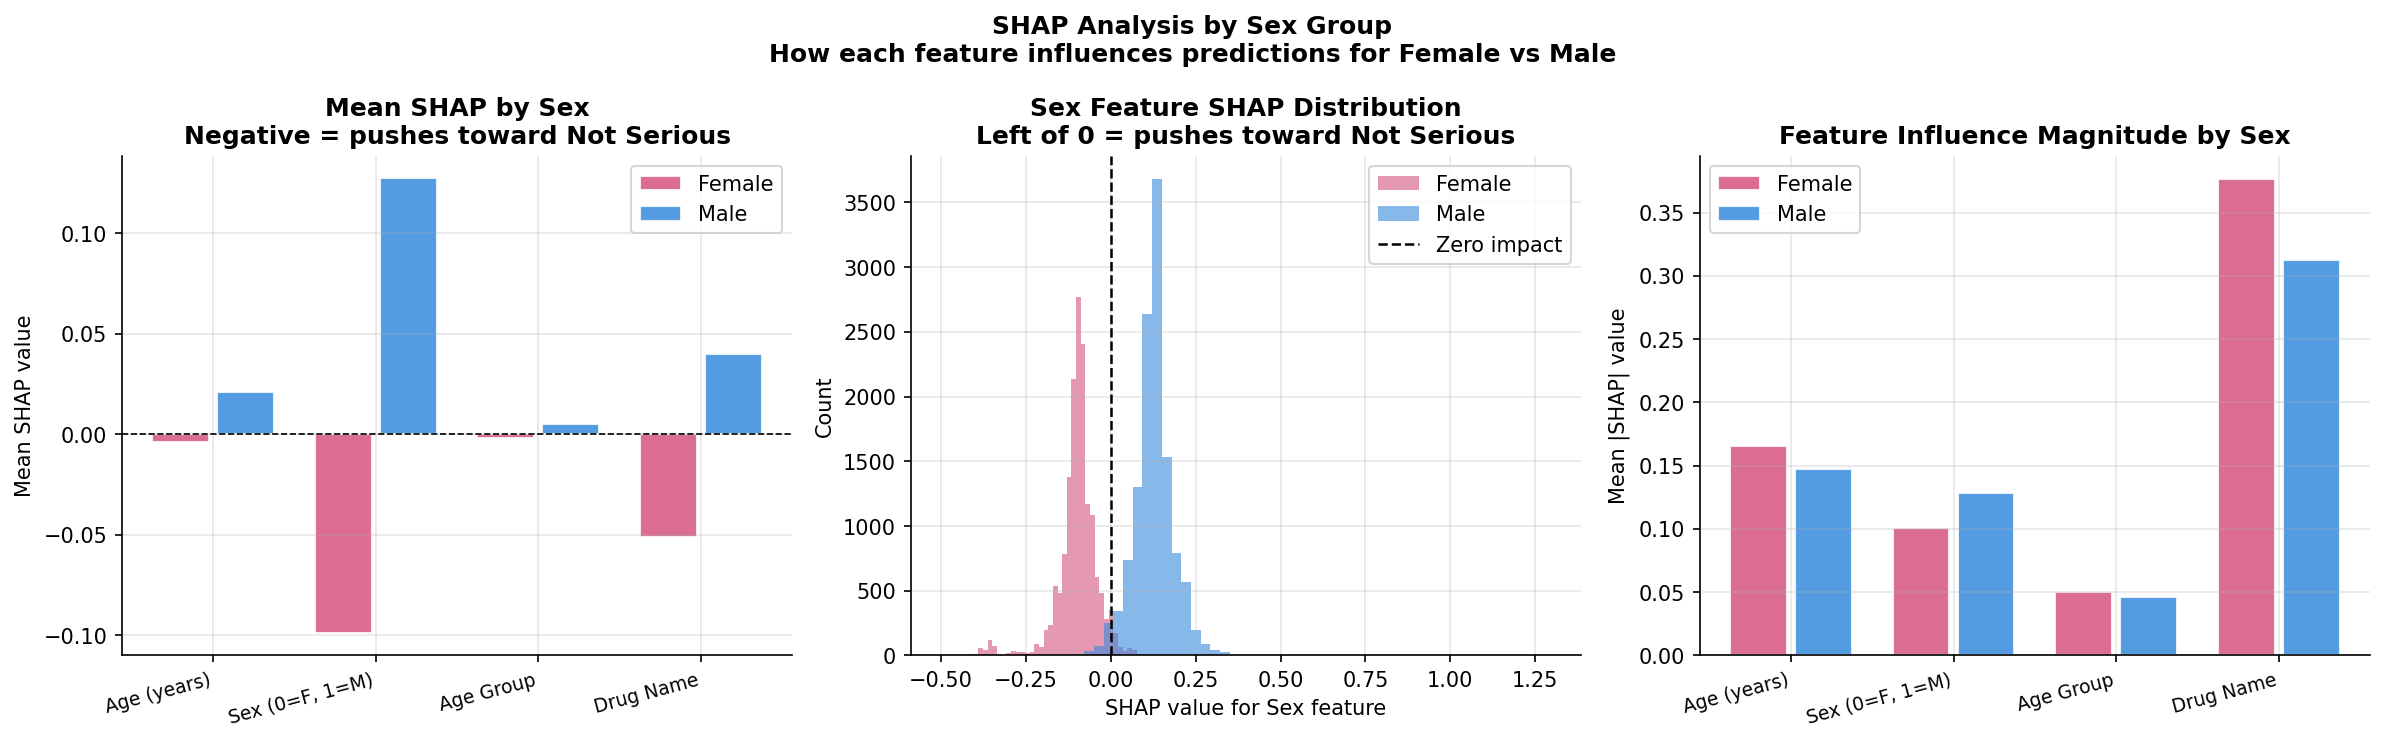

Saved: plots/14_shap_by_sex.png


In [ ]:
# ============================================================
# SHAP Comparison Plot Female vs Male
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SHAP Analysis by Sex Group\n'
             'How each feature influences predictions for Female vs Male',
             fontsize=12, fontweight='bold')

# ── Plot 1: Mean SHAP per feature per sex ────────────────
x       = np.arange(len(DISPLAY_NAMES))
f_means = [shap_female[:, i].mean() for i in range(len(FEATURES_B))]
m_means = [shap_male[:, i].mean()   for i in range(len(FEATURES_B))]

axes[0].bar(x - 0.2, f_means, 0.35,
            color='#D4537E', alpha=0.85,
            label='Female', edgecolor='white')
axes[0].bar(x + 0.2, m_means, 0.35,
            color='#378ADD', alpha=0.85,
            label='Male', edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xticks(x)
axes[0].set_xticklabels(DISPLAY_NAMES, rotation=15,
                         ha='right', fontsize=9)
axes[0].set_ylabel('Mean SHAP value')
axes[0].set_title('Mean SHAP by Sex\n'
                  'Negative = pushes toward Not Serious',
                  fontweight='bold')
axes[0].legend()

# ── Plot 2: SHAP distribution for Sex feature only ───────
axes[1].hist(shap_female[:, sex_idx], bins=50,
             color='#D4537E', alpha=0.6,
             label='Female', edgecolor='none')
axes[1].hist(shap_male[:, sex_idx],   bins=50,
             color='#378ADD', alpha=0.6,
             label='Male',   edgecolor='none')
axes[1].axvline(0, color='black', linewidth=1.2,
                linestyle='--', label='Zero impact')
axes[1].set_xlabel('SHAP value for Sex feature')
axes[1].set_ylabel('Count')
axes[1].set_title('Sex Feature SHAP Distribution\n'
                  'Left of 0 = pushes toward Not Serious',
                  fontweight='bold')
axes[1].legend()

# ── Plot 3: Mean |SHAP| per sex per feature ──────────────
f_abs = [np.abs(shap_female[:, i]).mean() for i in range(len(FEATURES_B))]
m_abs = [np.abs(shap_male[:, i]).mean()   for i in range(len(FEATURES_B))]

axes[2].bar(x - 0.2, f_abs, 0.35,
            color='#D4537E', alpha=0.85,
            label='Female', edgecolor='white')
axes[2].bar(x + 0.2, m_abs, 0.35,
            color='#378ADD', alpha=0.85,
            label='Male', edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(DISPLAY_NAMES, rotation=15,
                         ha='right', fontsize=9)
axes[2].set_ylabel('Mean |SHAP| value')
axes[2].set_title('Feature Influence Magnitude by Sex',
                  fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig(PLOTS_PATH + '14_shap_by_sex.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/14_shap_by_sex.png')


## SHAP Analysis by Age Group

* This examines how feature contributions vary across different age groups using SHAP values.

* Mean SHAP values are computed separately for each age group to compare the influence of individual features on model predictions.

* Visualisations are generated to show both the average SHAP values across features and the distribution of SHAP values for the age feature, providing insight into how the model's behaviour differs across age groups.

SHAP ANALYSIS BY AGE GROUP

Mean SHAP for sex_binary feature by age group:
(Shows how sex influences predictions in each age group)
---------------------------------------------
  paediatric     : +0.01925
  young_adult    : -0.03614
  middle_aged    : -0.00368
  elderly        : +0.01361


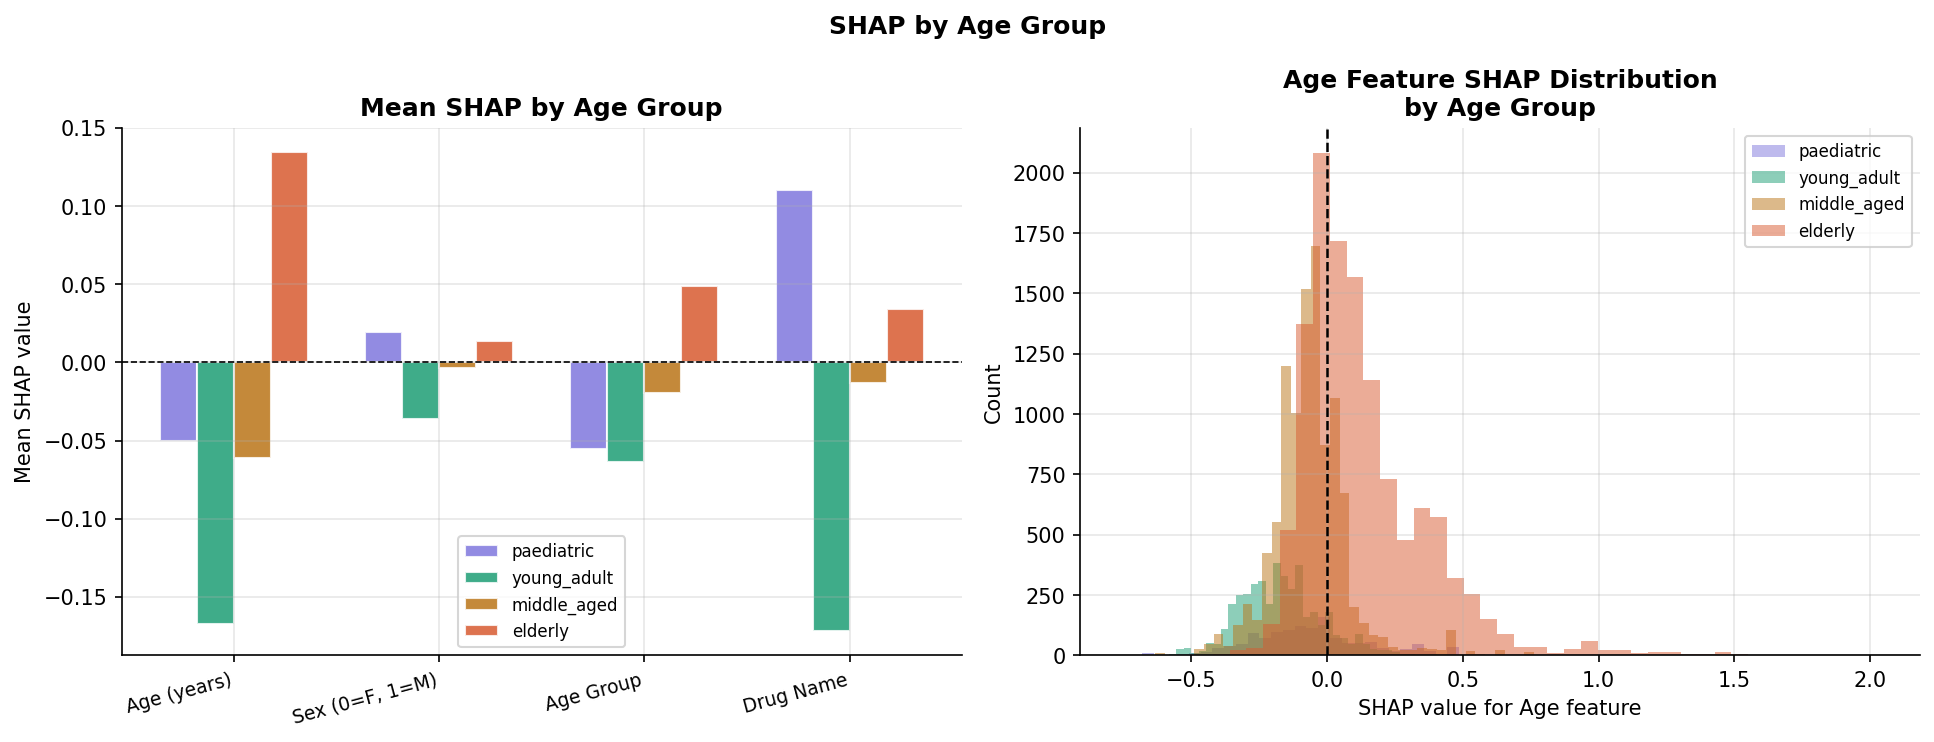

Saved: plots/15_shap_by_age.png


In [ ]:
# ============================================================
# SHAP by Age Group
# ============================================================

print('=' * 55)
print('SHAP ANALYSIS BY AGE GROUP')
print('=' * 55)

AGE_ORDER  = ['paediatric', 'young_adult', 'middle_aged', 'elderly']
age_colors = ['#7F77DD', '#1D9E75', '#BA7517', '#D85A30']

age_shap_means = {}
for ag in AGE_ORDER:
    mask = test_df['age_group'].values == ag
    if mask.sum() < 30:
        continue
    age_shap_means[ag] = shap_values[mask].mean(axis=0)

print(f'\nMean SHAP for sex_binary feature by age group:')
print('(Shows how sex influences predictions in each age group)')
print('-' * 45)
for ag, means in age_shap_means.items():
    print(f'  {ag:<15}: {means[sex_idx]:+.5f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('SHAP by Age Group', fontsize=12, fontweight='bold')

# Plot 1 — Mean SHAP per feature per age group
x = np.arange(len(FEATURES_B))
width = 0.18
for i, (ag, color) in enumerate(zip(
        age_shap_means.keys(), age_colors)):
    means = age_shap_means[ag]
    offset = (i - len(age_shap_means)/2 + 0.5) * width
    axes[0].bar(x + offset, means, width,
                color=color, alpha=0.85,
                label=ag, edgecolor='white')

axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xticks(x)
axes[0].set_xticklabels(DISPLAY_NAMES, rotation=15,
                         ha='right', fontsize=9)
axes[0].set_ylabel('Mean SHAP value')
axes[0].set_title('Mean SHAP by Age Group', fontweight='bold')
axes[0].legend(fontsize=8)

# Plot 2 — Age feature SHAP distribution
for ag, color in zip(age_shap_means.keys(), age_colors):
    mask = test_df['age_group'].values == ag
    axes[1].hist(shap_values[mask, age_idx], bins=40,
                 color=color, alpha=0.5,
                 label=ag, edgecolor='none')

axes[1].axvline(0, color='black', linewidth=1.2,
                linestyle='--')
axes[1].set_xlabel('SHAP value for Age feature')
axes[1].set_ylabel('Count')
axes[1].set_title('Age Feature SHAP Distribution\nby Age Group',
                  fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_PATH + '15_shap_by_age.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/15_shap_by_age.png')


In [ ]:
# ============================================================
# Missed Cases Analysis
# ============================================================

print('=' * 55)
print('SHAP FOR MISSED SERIOUS CASES (False Negatives)')
print('=' * 55)


# (same as pred_xgb_tuned when threshold=0.5 but explicit)
y_pred   = test_df['pred_optimal_thresh'].values

# False negatives = actual serious but predicted not serious
fn_mask  = (y_test == 1) & (y_pred == 0)
tp_mask  = (y_test == 1) & (y_pred == 1)

shap_fn  = shap_values[fn_mask]
shap_tp  = shap_values[tp_mask]

print(f'\nFalse Negatives (missed serious) : {fn_mask.sum():,}')
print(f'True Positives  (caught serious) : {tp_mask.sum():,}')

print(f'\nMean SHAP for missed vs caught serious cases:')
print(f'{"Feature":<20} {"Missed (FN)":>14} {"Caught (TP)":>14} {"Difference":>12}')
print('-' * 62)
for i, name in enumerate(DISPLAY_NAMES):
    fn_m = shap_fn[:, i].mean()
    tp_m = shap_tp[:, i].mean()
    diff = fn_m - tp_m
    print(f'{name:<20} {fn_m:>14.5f} {tp_m:>14.5f} {diff:>12.5f}')

# Female vs male FN comparison
print('\nFalse Negatives breakdown by sex:')
for sex, label in [('F','Female'), ('M','Male')]:
    sex_fn = fn_mask & (test_df['sex'].values == sex)
    total_sex_serious = ((y_test==1) & (test_df['sex'].values==sex)).sum()
    print(f'  {label}: {sex_fn.sum():,} missed '
          f'out of {total_sex_serious:,} serious '
          f'({sex_fn.sum()/total_sex_serious:.1%} FNR)')


SHAP FOR MISSED SERIOUS CASES (False Negatives)

False Negatives (missed serious) : 5,430
True Positives  (caught serious) : 10,161

Mean SHAP for missed vs caught serious cases:
Feature                 Missed (FN)    Caught (TP)   Difference
--------------------------------------------------------------
Age (years)                -0.09504        0.11052     -0.20556
Sex (0=F, 1=M)             -0.04826        0.04492     -0.09317
Age Group                  -0.02014        0.02285     -0.04298
Drug Name                  -0.19999        0.28037     -0.48037

False Negatives breakdown by sex:
  Female: 4,021 missed out of 8,326 serious (48.3% FNR)
  Male: 1,409 missed out of 7,265 serious (19.4% FNR)


Waterfall Plot for a Female False Negative

* This identifies a representative female false negative from the test set, where a serious adverse event was incorrectly classified as non-serious.

* A SHAP waterfall plot is then generated to visualise how individual feature contributions combine to produce the final prediction, providing a local explanation of why the model misclassified the selected case.

Streaming output truncated to the last 5000 lines.
[3190] Test Index : 22587
     Probability : 0.4455
     Age         : 42
     Drug        : hydroxyzine hydrochloride
     Reaction    : toxicity to various agents
----------------------------------------------------------------------
[3191] Test Index : 22589
     Probability : 0.4213
     Age         : 55
     Drug        : methotrexate
     Reaction    : herpes simplex hepatitis
----------------------------------------------------------------------
[3192] Test Index : 22605
     Probability : 0.4857
     Age         : 49
     Drug        : scemblix
     Reaction    : disturbance in attention
----------------------------------------------------------------------
[3193] Test Index : 22611
     Probability : 0.3967
     Age         : 4
     Drug        : unituxin
     Reaction    : pleural effusion
----------------------------------------------------------------------
[3194] Test Index : 22618
     Probability : 0.4685
     Age       

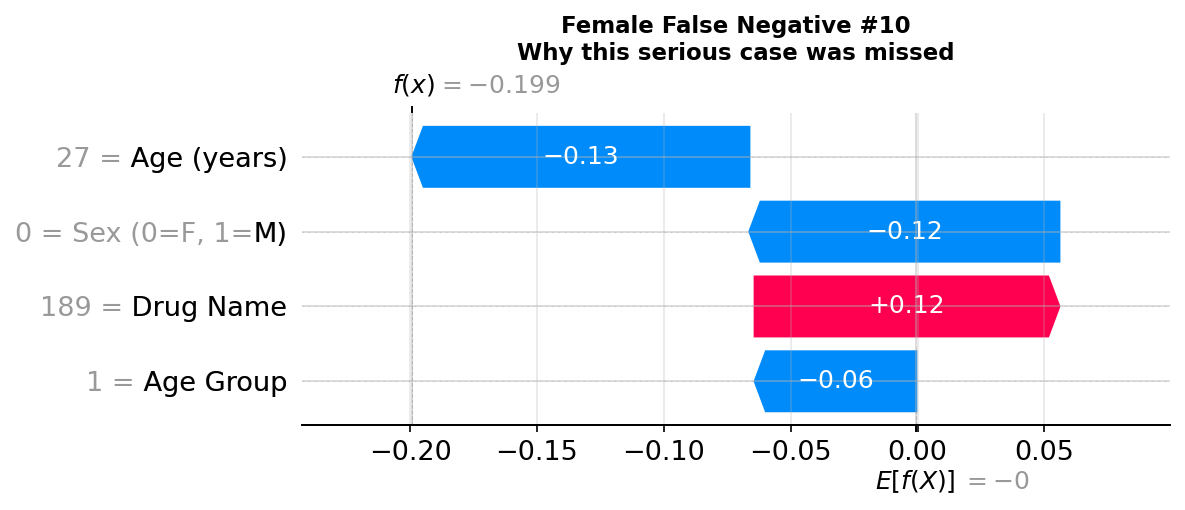

In [ ]:
# ============================================================
# WATERFALL PLOT: Select Any Female False Negative
# ============================================================

# Predictions
y_pred_all = test_df['pred_optimal_thresh'].values
fn_mask = (y_test == 1) & (y_pred_all == 0)

# Female False Negatives
fn_female_mask = fn_mask & (test_df['sex'].values == 'F')
fn_female_idx = np.where(fn_female_mask)[0]

if len(fn_female_idx) > 0:

    # Get probabilities
    proba_col = test_df.get(
        'proba_xgb_tuned',
        pd.Series(xgb_tuned.predict_proba(X_test_B)[:, 1])
    ).values

    print("=" * 70)
    print("AVAILABLE FEMALE FALSE NEGATIVES")
    print("=" * 70)

    for i, idx in enumerate(fn_female_idx):
        row = test_df.iloc[idx]

        print(f"[{i}] Test Index : {idx}")
        print(f"     Probability : {proba_col[idx]:.4f}")
        print(f"     Age         : {row['age_years']:.0f}")
        print(f"     Drug        : {row['drug_name']}")
        print(f"     Reaction    : {row['reaction']}")
        print("-" * 70)

    # ======================================================
    # 0 = first female
    # 1 = second female
    # 2 = third female
    # ======================================================
    patient_no = 10

    selected_idx = fn_female_idx[patient_no]

    print("\n")
    print("=" * 70)
    print("SELECTED FEMALE FALSE NEGATIVE")
    print("=" * 70)

    row = test_df.iloc[selected_idx]

    print(f"Patient index     : {selected_idx}")
    print("Actual outcome    : SERIOUS (1)")
    print("Prediction        : NOT SERIOUS (0)")
    print(f"Probability       : {proba_col[selected_idx]:.4f}")
    print(f"Sex               : {row['sex']}")
    print(f"Age               : {row['age_years']:.0f}")
    print(f"Age Group         : {row['age_group']}")
    print(f"Drug              : {row['drug_name']}")
    print(f"Reaction          : {row['reaction']}")

    # SHAP Explanation
    explanation = shap.Explanation(
        values=shap_values[selected_idx],
        base_values=explainer.expected_value,
        data=X_test_B[selected_idx],
        feature_names=DISPLAY_NAMES
    )

    plt.figure(figsize=(9,4))

    shap.waterfall_plot(explanation, show=False)

    plt.title(
        f"Female False Negative #{patient_no}\n"
        "Why this serious case was missed",
        fontsize=11,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        PLOTS_PATH + f"waterfall_female_FN_{patient_no}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

else:
    print("No female false negatives found.")

In [ ]:
# ============================================================
# SHAP Summary for Report
# ============================================================

print('=' * 60)
print('SHAP ANALYSIS COMPLETE: SUMMARY FOR REPORT')
print('=' * 60)

print('\n1. GLOBAL FEATURE IMPORTANCE')
for feat, val in sorted(
        zip(DISPLAY_NAMES, mean_abs_shap),
        key=lambda x: x[1], reverse=True):
    print(f'   {feat:<20}: {val:.5f}')

print('\n2. DEMOGRAPHIC FEATURE INFLUENCE')
print(f'   Sex mean |SHAP|   : {mean_abs_shap[sex_idx]:.5f}')
print(f'   Age mean |SHAP|   : {mean_abs_shap[age_idx]:.5f}')
print(f'   Drug mean |SHAP|  : {mean_abs_shap[drg_idx]:.5f}')

ratio_sex  = mean_abs_shap[sex_idx]  / mean_abs_shap[drg_idx]
ratio_age  = mean_abs_shap[age_idx]  / mean_abs_shap[drg_idx]
print(f'\n   Sex  importance vs Drug: {ratio_sex:.2f}x')
print(f'   Age  importance vs Drug: {ratio_age:.2f}x')

print('\n3. SEX DIRECTION OF INFLUENCE')
print(f'   Female mean SHAP (sex): {sex_f_mean:+.5f}')
print(f'   Male   mean SHAP (sex): {sex_m_mean:+.5f}')
if sex_f_mean < 0 and sex_m_mean > 0:
    print('   Sex feature pushes females toward NOT serious')
    print('   Sex feature pushes males toward SERIOUS')
    print('   Model has learned gender bias from training data')

# Save SHAP values
np.save(PROCESSED_PATH + 'shap_values.npy', shap_values)
shap_summary = pd.DataFrame(
    {'feature': DISPLAY_NAMES,
     'mean_abs_shap': mean_abs_shap}
).sort_values('mean_abs_shap', ascending=False)
shap_summary.to_csv(PROCESSED_PATH + 'shap_summary.csv', index=False)

print('\nSaved: shap_values.npy')
print('Saved: shap_summary.csv')


SHAP ANALYSIS COMPLETE: SUMMARY FOR REPORT

1. GLOBAL FEATURE IMPORTANCE
   Drug Name           : 0.34839
   Age (years)         : 0.15754
   Sex (0=F, 1=M)      : 0.11272
   Age Group           : 0.04868

2. DEMOGRAPHIC FEATURE INFLUENCE
   Sex mean |SHAP|   : 0.11272
   Age mean |SHAP|   : 0.15754
   Drug mean |SHAP|  : 0.34839

   Sex  importance vs Drug: 0.32x
   Age  importance vs Drug: 0.45x

3. SEX DIRECTION OF INFLUENCE
   Female mean SHAP (sex): -0.09866
   Male   mean SHAP (sex): +0.12719
   Sex feature pushes females toward NOT serious
   Sex feature pushes males toward SERIOUS
   Model has learned gender bias from training data

Saved: shap_values.npy
Saved: shap_summary.csv


In [2]:
 !cp '/content/drive/MyDrive/Ethics project/04_Shap_Analysis.ipynb' .

Mounted at /content/drive
Cloning into 'kulsoom2526'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 118 (delta 39), reused 0 (delta 0), pack-reused 3 (from 1)
Receiving objects: 100% (118/118), 53.42 MiB | 2.64 MiB/s, done.
Resolving deltas: 100% (39/39), done.
Updating files: 100% (19/19), done.
/content/kulsoom2526/Notebooks
